In [ ]:
## CUDA

In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

In [ ]:
## OnLy CPU

In [ ]:
!pip install torch torchvision

In [1]:
import torch
import torchvision

print("✅ PyTorch version:", torch.__version__)
print("✅ Torchvision version:", torchvision.__version__)
print("✅ CUDA acceleration available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("🛸 Active GPU Device:", torch.cuda.get_device_name(0))

✅ PyTorch version: 2.5.1+cu121
✅ Torchvision version: 0.20.1+cu121
✅ CUDA acceleration available: True
🛸 Active GPU Device: NVIDIA GeForce RTX 2080 SUPER


In [2]:
import os

DATASET_PATH = "dataset/PCB_DATASET"

# --- 1. File System Overview ---
print(f"\n[SECTION 1] Directory Inspection: {DATASET_PATH}")
print("-" * 40)
count = 0
for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        # if count < 10:  # Show first 10 files as examples
        #     print(f"Found: {os.path.join(root, file)}")
        #     count += 1
        print(f"Found: {os.path.join(root, file)}")
if count == 0:
    print("Warning: No files found. Please check your path.")


[SECTION 1] Directory Inspection: dataset/PCB_DATASET
----------------------------------------
Found: dataset/PCB_DATASET\rotate.py
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_01.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_02.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_03.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_04.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_05.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_06.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_07.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_08.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_09.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_10.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_11.xml
Found: dataset/PCB_DATASET\Annotations\Mis

In [ ]:
## Import & Parameter

In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt

# Ensure scikit-image is available for SSIM-NET simulation
try:
    from skimage.metrics import structural_similarity as ssim
except ImportError:
    # Fallback message to assist in setting up the environment
    raise ImportError("Please install scikit-image using: pip install scikit-image")

# Set up global parameters for comparison algorithm input requirements
TARGET_SIZE = (224, 224) # Standard input size for LPViT, ResNet, MobileNet, and AlexNet
PIXELS_PER_MM = 15.0     # Default spatial calibration factor

print("✅ Initialization complete. Target patch dimension set to:", TARGET_SIZE)

C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
C:\ProgramData\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


✅ Initialization complete. Target patch dimension set to: (224, 224)


In [4]:
## Preprocessing Module

In [5]:
def denoise_image(image, method='gaussian', ksize=5):
    """
    Apply spatial filtering to reduce high-frequency noise from optical capture.
    """
    if method == 'gaussian':
        return cv2.GaussianBlur(image, (ksize, ksize), 0)
    elif method == 'median':
        return cv2.medianBlur(image, ksize)
    return image

def enhance_contrast_clahe(image):
    """
    Apply CLAHE (Contrast Limited Adaptive Histogram Equalization).
    Highly effective for distinguishing copper traces from PCB substrate under varying lighting.
    """
    if len(image.shape) == 3:
        # Convert to LAB color space to apply CLAHE to the L (luminance) channel
        lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        cl = clahe.apply(l)
        enhanced_lab = cv2.merge((cl, a, b))
        return cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)
    else:
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        return clahe.apply(image)

def binarize_image(image, block_size=11, c_val=2):
    """
    Convert image to binary (black and white).
    Essential preprocessing step for the Auto-VRS XOR difference pipeline.
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if len(image.shape) == 3 else image
    # Use adaptive thresholding to account for uneven illumination across the board
    binary = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv2.THRESH_BINARY, block_size, c_val
    )
    return binary

print("✅ Preprocessing functions loaded.")

✅ Preprocessing functions loaded.


In [6]:
## Image Calibration & Rectification Module

In [7]:
class PCBCalibrator:
    def __init__(self, pixels_per_mm=15.0):
        self.pixels_per_mm = pixels_per_mm

    def pixel_to_physical(self, pixel_val):
        """Converts pixel distance to physical measurements (mm)"""
        return pixel_val / self.pixels_per_mm

    def rectify_and_align(self, src_img, ref_img):
        """
        Detects ORB features to align and warp the target image to match 
        the geometry of the template reference image.
        """
        # Convert both images to grayscale for keypoint detection
        gray_src = cv2.cvtColor(src_img, cv2.COLOR_BGR2GRAY) if len(src_img.shape) == 3 else src_img
        gray_ref = cv2.cvtColor(ref_img, cv2.COLOR_BGR2GRAY) if len(ref_img.shape) == 3 else ref_img

        # Initialize ORB detector
        orb = cv2.ORB_create(nfeatures=5000)
        kp1, des1 = orb.detectAndCompute(gray_src, None)
        kp2, des2 = orb.detectAndCompute(gray_ref, None)

        if des1 is None or des2 is None:
            # Fallback if feature descriptors cannot be established
            return src_img

        # Perform brute-force Hamming match
        bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
        matches = sorted(bf.match(des1, des2), key=lambda x: x.distance)

        # Select top-tier matches
        good_matches = matches[:120]
        src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
        ref_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

        # Calculate Perspective Homography Matrix and warp the source image
        H, mask = cv2.findHomography(src_pts, ref_pts, cv2.RANSAC, 5.0)
        height, width = ref_img.shape[:2]
        rectified_image = cv2.warpPerspective(src_img, H, (width, height))
        
        return rectified_image

print("✅ Calibration and spatial rectification module loaded.")

✅ Calibration and spatial rectification module loaded.


In [8]:
## Detection & Patch Extraction for the 4 Algorithm

In [9]:
class PCBCalibrator:
    def __init__(self, pixels_per_mm=15.0):
        self.pixels_per_mm = pixels_per_mm

    def pixel_to_physical(self, pixel_val):
        """Converts pixel distance to physical measurements (mm)"""
        return pixel_val / self.pixels_per_mm

    def rectify_and_align(self, src_img, ref_img):
        """
        Detects ORB features to align and warp the target image to match 
        the geometry of the template reference image.
        """
        # Convert both images to grayscale for keypoint detection
        gray_src = cv2.cvtColor(src_img, cv2.COLOR_BGR2GRAY) if len(src_img.shape) == 3 else src_img
        gray_ref = cv2.cvtColor(ref_img, cv2.COLOR_BGR2GRAY) if len(ref_img.shape) == 3 else ref_img

        # Initialize ORB detector
        orb = cv2.ORB_create(nfeatures=5000)
        kp1, des1 = orb.detectAndCompute(gray_src, None)
        kp2, des2 = orb.detectAndCompute(gray_ref, None)

        if des1 is None or des2 is None:
            # Fallback if feature descriptors cannot be established
            return src_img

        # Perform brute-force Hamming match
        bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
        matches = sorted(bf.match(des1, des2), key=lambda x: x.distance)

        # Select top-tier matches
        good_matches = matches[:120]
        src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
        ref_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

        # Calculate Perspective Homography Matrix and warp the source image
        H, mask = cv2.findHomography(src_pts, ref_pts, cv2.RANSAC, 5.0)
        height, width = ref_img.shape[:2]
        rectified_image = cv2.warpPerspective(src_img, H, (width, height))
        
        return rectified_image

print("✅ Calibration and spatial rectification module loaded.")

✅ Calibration and spatial rectification module loaded.


In [10]:
# ==============================================================================
# MISSING CELL: PATCH & ROI EXTRACTION MODULE FOR THE 4 ALGORITHMS
# ==============================================================================

def extract_ground_truth_patches(image, xml_path, target_size=TARGET_SIZE):
    """
    Pipeline 1: Supervised Ground-Truth Extraction (for LPViT & CS-ResNet).
    Parses the XML annotations and crops patches of exact defect zones, 
    resizing them to 224x224 to feed directly into deep learning networks.
    """
    if not os.path.exists(xml_path):
        return []
    
    tree = ET.parse(xml_path)
    root = tree.getroot()
    patches = []
    
    for obj in root.findall('object'):
        name = obj.find('name').text
        bndbox = obj.find('bndbox')
        xmin = int(float(bndbox.find('xmin').text))
        ymin = int(float(bndbox.find('ymin').text))
        xmax = int(float(bndbox.find('xmax').text))
        ymax = int(float(bndbox.find('ymax').text))
        
        # Ensure bounding box coordinates are within image boundaries
        h, w = image.shape[:2]
        xmin, ymin = max(0, xmin), max(0, ymin)
        xmax, ymax = min(w, xmax), min(h, ymax)
        
        # Crop and resize
        crop = image[ymin:ymax, xmin:xmax]
        if crop.size > 0:
            resized_patch = cv2.resize(crop, target_size)
            patches.append({"class": name, "patch": resized_patch, "coords": (xmin, ymin, xmax, ymax)})
            
    return patches

def extract_ssim_net_rois(rectified_img, ref_img, ssim_threshold=0.6, target_size=TARGET_SIZE):
    """
    Pipeline 2: SSIM-NET Pre-localization (for MobileNetV3 input).
    Calculates structural similarity mapping between target and template.
    Locates degraded structural areas, filters out noise, and crops patches 
    of structural anomalies as inputs for MobileNetV3.
    """
    # SSIM requires grayscale inputs
    gray_rect = cv2.cvtColor(rectified_img, cv2.COLOR_BGR2GRAY) if len(rectified_img.shape) == 3 else rectified_img
    gray_ref = cv2.cvtColor(ref_img, cv2.COLOR_BGR2GRAY) if len(ref_img.shape) == 3 else ref_img
    
    # Calculate SSIM full map
    score, diff_map = ssim(gray_rect, gray_ref, full=True)
    
    # Convert similarity mapping to a difference mask
    diff_map = (diff_map * 255).astype("uint8")
    _, thresh = cv2.threshold(diff_map, int(ssim_threshold * 255), 255, cv2.THRESH_BINARY_INV)
    
    # Locate contours of highly dissimilar structures
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    rois = []
    
    for ctr in contours:
        # Ignore minute noise perturbations using area constraint
        if cv2.contourArea(ctr) > 80:
            x, y, w, h = cv2.boundingRect(ctr)
            crop = rectified_img[y:y+h, x:x+w]
            if crop.size > 0:
                resized_patch = cv2.resize(crop, target_size)
                rois.append({"patch": resized_patch, "coords": (x, y, x + w, y + h)})
                
    return rois

def extract_auto_vrs_rois(rectified_img, ref_img, min_area=50, target_size=TARGET_SIZE):
    """
    Pipeline 3: Auto-VRS XOR Difference (for AlexNet input).
    Performs binarization, executes a bitwise XOR to highlight geometric deviation,
    and isolates structural changes as candidates for AlexNet pseudo-defect verification.
    """
    # 1. Binarize both template and target
    bin_rect = binarize_image(rectified_img)
    bin_ref = binarize_image(ref_img)
    
    # 2. Execute Microsecond-level Logical XOR Difference
    xor_diff = cv2.bitwise_xor(bin_rect, bin_ref)
    
    # 3. Clean noise and close gap structures
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    clean_diff = cv2.morphologyEx(xor_diff, cv2.MORPH_CLOSE, kernel)
    
    # 4. Extract contours of geometric differences
    contours, _ = cv2.findContours(clean_diff, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    rois = []
    
    for ctr in contours:
        if cv2.contourArea(ctr) > min_area:
            x, y, w, h = cv2.boundingRect(ctr)
            crop = rectified_img[y:y+h, x:x+w]
            if crop.size > 0:
                resized_patch = cv2.resize(crop, target_size)
                rois.append({"patch": resized_patch, "coords": (x, y, x + w, y + h)})
                
    return rois

print("✅ Bounding box and patch generators successfully built.")

✅ Bounding box and patch generators successfully built.


In [11]:
## Pipeline Execution & Comparative Visualization

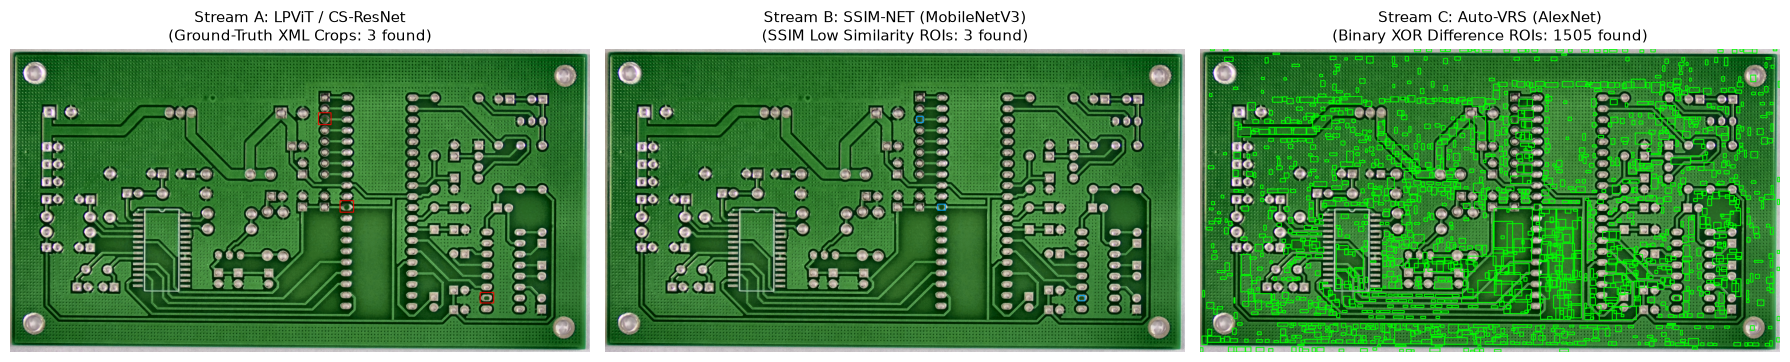

📊 Patch generation summary ready for comparison models:
   -> LPViT/ResNet patch dimensions: (224, 224, 3) (Ready for network train/val)
   -> MobileNetV3 patch dimensions: (224, 224, 3) (Ready for inference evaluation)
   -> AlexNet patch dimensions: (224, 224, 3) (Ready for pseudo-defect sorting)


In [12]:
# Configure paths to matching PCB pairs from your dataset
# (Using the DATASET_PATH variable defined in your directory inspection)
DATASET_PATH = "dataset/PCB_DATASET"

TEST_TARGET_PATH = os.path.join(DATASET_PATH, "images/Missing_hole/01_missing_hole_01.jpg")
TEST_TEMPLATE_PATH = os.path.join(DATASET_PATH, "PCB_USED/01.JPG")
TEST_XML_PATH = os.path.join(DATASET_PATH, "Annotations/Missing_hole/01_missing_hole_01.xml")

# Verify sample availability
if not os.path.exists(TEST_TARGET_PATH) or not os.path.exists(TEST_TEMPLATE_PATH):
    print(f"⚠️ Please verify that dataset paths match your folder structure.")
    print(f"Looked for target at: {TEST_TARGET_PATH}")
    print(f"Looked for template at: {TEST_TEMPLATE_PATH}")
else:
    # 1. Read Raw Images
    raw_target = cv2.imread(TEST_TARGET_PATH)
    raw_template = cv2.imread(TEST_TEMPLATE_PATH)
    
    # 2. Execute Preprocessing & Calibration (functions defined in preceding cells)
    preprocessed_target = enhance_contrast_clahe(denoise_image(raw_target, 'gaussian', 5))
    preprocessed_template = enhance_contrast_clahe(denoise_image(raw_template, 'gaussian', 5))
    
    calibrator = PCBCalibrator(pixels_per_mm=PIXELS_PER_MM)
    aligned_target = calibrator.rectify_and_align(preprocessed_target, preprocessed_template)
    
    # 3. Extract Patches for Comparative Algorithms
    # Stream A: LPViT / CS-ResNet Ground Truth crops
    gt_patches = extract_ground_truth_patches(aligned_target, TEST_XML_PATH)
    
    # Stream B: SSIM-NET (MobileNetV3 inputs)
    ssim_rois = extract_ssim_net_rois(aligned_target, preprocessed_template, ssim_threshold=0.7)
    
    # Stream C: Auto-VRS (AlexNet input candidates via XOR)
    xor_rois = extract_auto_vrs_rois(aligned_target, preprocessed_template)
    
    # 4. Generate Comparative Visualizations
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Frame 1: LPViT / CS-ResNet Visual Verification
    annotated_a = aligned_target.copy()
    for patch in gt_patches:
        x1, y1, x2, y2 = patch["coords"]
        cv2.rectangle(annotated_a, (x1, y1), (x2, y2), (0, 0, 255), 4)
    axes[0].imshow(cv2.cvtColor(annotated_a, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Stream A: LPViT / CS-ResNet\n(Ground-Truth XML Crops: {len(gt_patches)} found)", fontsize=11)
    axes[0].axis('off')
    
    # Frame 2: SSIM-NET (MobileNetV3) Visual Verification
    annotated_b = aligned_target.copy()
    for roi in ssim_rois:
        x1, y1, x2, y2 = roi["coords"]
        cv2.rectangle(annotated_b, (x1, y1), (x2, y2), (255, 165, 0), 4)
    axes[1].imshow(cv2.cvtColor(annotated_b, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"Stream B: SSIM-NET (MobileNetV3)\n(SSIM Low Similarity ROIs: {len(ssim_rois)} found)", fontsize=11)
    axes[1].axis('off')
    
    # Frame 3: Auto-VRS (AlexNet) Visual Verification
    annotated_c = aligned_target.copy()
    for roi in xor_rois:
        x1, y1, x2, y2 = roi["coords"]
        cv2.rectangle(annotated_c, (x1, y1), (x2, y2), (0, 255, 0), 4)
    axes[2].imshow(cv2.cvtColor(annotated_c, cv2.COLOR_BGR2RGB))
    axes[2].set_title(f"Stream C: Auto-VRS (AlexNet)\n(Binary XOR Difference ROIs: {len(xor_rois)} found)", fontsize=11)
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Output metrics verifying input sizes
    print(f"📊 Patch generation summary ready for comparison models:")
    if gt_patches:
        print(f"   -> LPViT/ResNet patch dimensions: {gt_patches[0]['patch'].shape} (Ready for network train/val)")
    if ssim_rois:
        print(f"   -> MobileNetV3 patch dimensions: {ssim_rois[0]['patch'].shape} (Ready for inference evaluation)")
    if xor_rois:
        print(f"   -> AlexNet patch dimensions: {xor_rois[0]['patch'].shape} (Ready for pseudo-defect sorting)")

In [13]:
import os
import random
import shutil
import cv2

# --- 1. Configure Input/Output Paths ---
DATASET_PATH = "dataset/PCB_DATASET"
OUTPUT_DIR = "dataset_processed"  # Directory where the standardized classification dataset will be saved
SPLIT_RATIO = 0.8  # 80% for training set, 20% for validation set

# Target class names (corresponds to directory names)
CLASS_NAMES = ["Missing_hole", "Mouse_bite", "Open_circuit", "Short", "Spur", "Spurious_copper"]

# Ensure the output directory is clean/empty before generating new data
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

# Create output subdirectories for splits
for split in ["train", "val"]:
    for cls in CLASS_NAMES:
        os.makedirs(os.path.join(OUTPUT_DIR, split, cls), exist_ok=True)

# --- 2. Core Batch Extraction Function ---
def batch_generate_dataset():
    print("⏳ Starting batch generation... This may take a moment.")
    
    calibrator = PCBCalibrator(pixels_per_mm=PIXELS_PER_MM)
    total_processed_patches = 0
    
    # Iterate through the 6 defect classes
    for cls in CLASS_NAMES:
        annotations_dir = os.path.join(DATASET_PATH, "Annotations", cls)
        if not os.path.exists(annotations_dir):
            continue
            
        xml_files = [f for f in os.listdir(annotations_dir) if f.endswith('.xml')]
        
        # Shuffle files randomly to facilitate training and validation splitting
        random.seed(42)  # Fix random seed to ensure reproducibility
        random.shuffle(xml_files)
        
        split_idx = int(len(xml_files) * SPLIT_RATIO)
        
        for idx, xml_file in enumerate(xml_files):
            # 1. Parse file name to identify template prefix
            # Example: "01_missing_hole_01.xml" -> template prefix is "01"
            template_prefix = xml_file.split('_')[0]
            
            # Handle image file extension case sensitivity
            # Reference/Template is usually uppercase .JPG, target is lowercase .jpg
            template_img_path = os.path.join(DATASET_PATH, "PCB_USED", f"{template_prefix}.JPG")
            if not os.path.exists(template_img_path):
                template_img_path = os.path.join(DATASET_PATH, "PCB_USED", f"{template_prefix}.jpg")
                
            img_file_name = xml_file.replace('.xml', '.jpg')
            target_img_path = os.path.join(DATASET_PATH, "images", cls, img_file_name)
            xml_path = os.path.join(annotations_dir, xml_file)
            
            # Verify file completeness
            if not os.path.exists(target_img_path) or not os.path.exists(template_img_path):
                print(f"⚠️ Warning: Missing image or template for {xml_file}. Skipping.")
                continue
                
            # 2. Read images and align them
            raw_target = cv2.imread(target_img_path)
            raw_template = cv2.imread(template_img_path)
            
            # Preprocessing and geometric alignment
            prep_target = enhance_contrast_clahe(denoise_image(raw_target, 'gaussian', 5))
            prep_template = enhance_contrast_clahe(denoise_image(raw_template, 'gaussian', 5))
            aligned_target = calibrator.rectify_and_align(prep_target, prep_template)
            
            # 3. Extract defect patches
            patches = extract_ground_truth_patches(aligned_target, xml_path, target_size=TARGET_SIZE)
            
            # 4. Assign the patch to either training or validation set
            target_split = "train" if idx < split_idx else "val"
            
            # 5. Save the generated defect patches
            for p_idx, patch_data in enumerate(patches):
                patch_img = patch_data["patch"]
                # Filename format: {original_filename}_p{defect_index}.jpg
                save_name = f"{xml_file.replace('.xml', '')}_p{p_idx}.jpg"
                save_path = os.path.join(OUTPUT_DIR, target_split, cls, save_name)
                
                # Write to disk
                cv2.imwrite(save_path, patch_img)
                total_processed_patches += 1
                
        print(f"✅ Processed class '{cls}': {len(xml_files)} images parsed.")
        
    print(f"\n🎉 Done! Generated {total_processed_patches} patches in total under folder '{OUTPUT_DIR}'.")

# Run batch processing
batch_generate_dataset()

⏳ Starting batch generation... This may take a moment.
✅ Processed class 'Missing_hole': 115 images parsed.
✅ Processed class 'Mouse_bite': 115 images parsed.
✅ Processed class 'Open_circuit': 116 images parsed.
✅ Processed class 'Short': 116 images parsed.
✅ Processed class 'Spur': 115 images parsed.
✅ Processed class 'Spurious_copper': 116 images parsed.

🎉 Done! Generated 2953 patches in total under folder 'dataset_processed'.


In [14]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
from collections import Counter

# --- 1. Define Standard ImageNet Normalization and Augmentations ---
# Adding geometric rotations is safe and realistic for PCB defect patterns
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    # Normalize using standard ImageNet mean and standard deviation
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- 2. Load Datasets using ImageFolder ---
PROCESSED_DIR = "dataset_processed"
train_dataset = datasets.ImageFolder(root=os.path.join(PROCESSED_DIR, "train"), transform=train_transforms)
val_dataset = datasets.ImageFolder(root=os.path.join(PROCESSED_DIR, "val"), transform=val_transforms)

# Define PyTorch DataLoaders (Batch size can be adjusted based on GPU memory)
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

# --- 3. Compute Class Distribution and Cost-Sensitive Weights ---
# Collect labels from the training subset
train_labels = [label for _, label in train_dataset.samples]
class_counts = Counter(train_labels)

print("📊 Training Dataset Distribution:")
print("-" * 50)
total_samples = sum(class_counts.values())
class_weights = []

# Order of indices matches PyTorch's class_to_idx mapping
for idx, class_name in enumerate(train_dataset.classes):
    count = class_counts[idx]
    percentage = (count / total_samples) * 100
    print(f"Index {idx} | Class: {class_name:<16} | Count: {count:<5} | Share: {percentage:.2f}%")
    
    # Calculate inverse frequency weight (Cost-Sensitive weights)
    # A smaller class count results in a larger loss weight to penalize errors on minority classes
    weight = total_samples / (len(train_dataset.classes) * count)
    class_weights.append(weight)

# Convert to PyTorch tensor to be consumed by nn.CrossEntropyLoss
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print("-" * 50)
print("⚖️ Computed Cost-Sensitive Loss Weights (for CS-ResNet):")
for idx, class_name in enumerate(train_dataset.classes):
    print(f"Class: {class_name:<16} -> Loss Weight: {class_weights[idx]:.4f}")

print(f"\n✅ PyTorch Dataloaders established using Device: {device}")

📊 Training Dataset Distribution:
--------------------------------------------------
Index 0 | Class: Missing_hole     | Count: 402   | Share: 16.89%
Index 1 | Class: Mouse_bite       | Count: 403   | Share: 16.93%
Index 2 | Class: Open_circuit     | Count: 383   | Share: 16.09%
Index 3 | Class: Short            | Count: 390   | Share: 16.39%
Index 4 | Class: Spur             | Count: 398   | Share: 16.72%
Index 5 | Class: Spurious_copper  | Count: 404   | Share: 16.97%
--------------------------------------------------
⚖️ Computed Cost-Sensitive Loss Weights (for CS-ResNet):
Class: Missing_hole     -> Loss Weight: 0.9867
Class: Mouse_bite       -> Loss Weight: 0.9843
Class: Open_circuit     -> Loss Weight: 1.0357
Class: Short            -> Loss Weight: 1.0171
Class: Spur             -> Loss Weight: 0.9966
Class: Spurious_copper  -> Loss Weight: 0.9818

✅ PyTorch Dataloaders established using Device: cuda


In [15]:
## GPU vs CPU split

In [17]:
import os
import torch
import torch.nn as nn
import torchvision.models as models

# ==============================================================================
# 1. MODEL ARCHITECTURE DEFINITIONS
# ==============================================================================

# --- MODEL 1: LPViT (Lightweight Custom Vision Transformer) ---
class PatchEmbedding(nn.Module):
    """
    Splits the 224x224 image into 16x16 non-overlapping patches,
    and projects them into a 128-dimensional embedding space.
    """
    def __init__(self, img_size=224, patch_size=16, in_channels=3, embed_dim=128):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        # Project patches using a 2D convolution with stride equal to patch size
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x shape: [Batch, 3, 224, 224] -> [Batch, embed_dim, 14, 14]
        x = self.proj(x)
        # Flatten spatial dimensions and transpose: [Batch, 14*14, embed_dim]
        x = x.flatten(2).transpose(1, 2)
        return x

class LightweightViT(nn.Module):
    """
    A custom compact Vision Transformer simulating the multi-head self-attention
    pipeline of LPViT, tailored to train and infer smoothly on CPU resources.
    """
    def __init__(self, img_size=224, patch_size=16, num_classes=6, embed_dim=128, depth=4, num_heads=4, mlp_ratio=4.0):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, 3, embed_dim)
        
        # Learnable Class Token (representing aggregate defect signature)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        # Learnable Position Embeddings
        self.pos_embed = nn.Parameter(torch.zeros(1, self.patch_embed.num_patches + 1, embed_dim))
        
        # Transformer Encoder Blocks (Multi-Head Self-Attention)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, 
            nhead=num_heads, 
            dim_feedforward=int(embed_dim * mlp_ratio),
            batch_first=True,
            activation='gelu'
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        
        # Final classification MLP head
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        batch_size = x.shape[0]
        x = self.patch_embed(x)
        
        # Prepend class token to patch embeddings sequence
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        
        # Add spatial position indicators
        x = x + self.pos_embed
        
        # Feed through Transformer sequence encoder
        x = self.transformer(x)
        
        # Classify using solely the output representation from the class token
        class_token_out = x[:, 0]
        return self.mlp_head(class_token_out)

# --- MODEL 2: CS-ResNet (Cost-Sensitive Residual Network) ---
def get_cs_resnet(num_classes=6):
    """
    Standard ResNet-18. We will inject the cost-sensitive weights 
    into its Loss Function during training.
    """
    model = models.resnet18(weights=None)
    # Re-map final layer to match our 6 PCB defect categories
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

# --- MODEL 3: MobileNetV3 (Lightweight CPU-optimized CNN) ---
def get_mobilenet_v3(num_classes=6):
    """
    Optimized for high-speed edge deployment on mobile/CPU nodes.
    """
    model = models.mobilenet_v3_small(weights=None)
    # Re-map classifier layer
    model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)
    return model

# --- MODEL 4: AlexNet (Auto-VRS CNN Class Classifier Component) ---
def get_alexnet(num_classes=6):
    """
    Classic simple network used in the Auto-VRS pipeline.
    """
    model = models.alexnet(weights=None)
    # Re-map the final fully-connected classifier layer
    model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    return model


# ==============================================================================
# 2. MULTI-DEVICE ALLOCATION & INSTANTIATION
# ==============================================================================

# --- Setup Specific Devices ---
# GPU Group targets NVIDIA GPU (CUDA) if available
if torch.cuda.is_available():
    device_gpu = torch.device("cuda")
    print("🚀 GPU Group: Mapped to NVIDIA GPU (CUDA) acceleration.")
else:
    device_gpu = torch.device("cpu")
    print("⚠️ GPU Group: CUDA not detected. Temporarily mapping LPViT & CS-ResNet to CPU.")

# CPU Group is explicitly anchored to the host processor (CPU)
device_cpu = torch.device("cpu")
print("💻 CPU Group: MobileNetV3 and AlexNet (Auto-VRS) are anchored to CPU execution.")
print("-" * 65)

# --- Instantiate Models on Dedicated Hardware ---
lpvit_sim = LightweightViT().to(device_gpu)
cs_resnet = get_cs_resnet().to(device_gpu)
mobilenet = get_mobilenet_v3().to(device_cpu)
alexnet = get_alexnet().to(device_cpu)

# Helper function to summarize parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("📐 Standard Production Allocation & Parameters:")
print("-" * 65)
print(f"1. LPViT (Lightweight ViT)  -> [GPU]: {count_parameters(lpvit_sim):,} params")
print(f"2. CS-ResNet (ResNet18)     -> [GPU]: {count_parameters(cs_resnet):,} params")
print(f"3. MobileNetV3 (Small)      -> [CPU]: {count_parameters(mobilenet):,} params")
print(f"4. AlexNet (Auto-VRS-CNN)   -> [CPU]: {count_parameters(alexnet):,} params")
print("-" * 65)
print("✅ All class definitions and device allocations are loaded successfully!")

🚀 GPU Group: Mapped to NVIDIA GPU (CUDA) acceleration.
💻 CPU Group: MobileNetV3 and AlexNet (Auto-VRS) are anchored to CPU execution.
-----------------------------------------------------------------
📐 Standard Production Allocation & Parameters:
-----------------------------------------------------------------
1. LPViT (Lightweight ViT)  -> [GPU]: 917,894 params
2. CS-ResNet (ResNet18)     -> [GPU]: 11,179,590 params
3. MobileNetV3 (Small)      -> [CPU]: 1,524,006 params
4. AlexNet (Auto-VRS-CNN)   -> [CPU]: 57,028,422 params
-----------------------------------------------------------------
✅ All class definitions and device allocations are loaded successfully!


In [29]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Try to import seaborn for high-quality confusion matrix plotting
try:
    import seaborn as sns
except ImportError:
    raise ImportError("Please install seaborn using: pip install seaborn")

# ==============================================================================
# 1. DEFINE SELF-CONTAINED INDUSTRIAL EVALUATION METRIC FUNCTION
# ==============================================================================

def evaluate_industrial_metrics(model, dataloader, device, model_name="Model"):
    """
    Evaluates the model to produce an industrial-grade report with 
    Precision, Recall, F1-Score per class, and plots a Confusion Matrix.
    """
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            # Send batch inputs to the model's assigned device (GPU or CPU)
            images = images.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)
            
            # Store predictions and ground truths as CPU numpy arrays
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # 1. Generate Classification Report (Precision, Recall, F1-Score per Class)
    print(f"\n" + "=" * 65)
    print(f"📋 INDUSTRIAL CLASSIFICATION REPORT FOR: {model_name}")
    print(f"📍 Execution Device: {device}")
    print("=" * 65)
    class_names = dataloader.dataset.classes
    report = classification_report(all_labels, all_preds, target_names=class_names, zero_division=0)
    print(report)
    print("=" * 65)
    
    # 2. Calculate and Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(5, 3))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names,
        cbar=False, annot_kws={"size": 11, "weight": "bold"}
    )
    plt.title(f"Confusion Matrix - {model_name}", fontsize=13, pad=15, weight='bold')
    plt.ylabel("Actual Defect Class (Ground Truth)", fontsize=10)
    plt.xlabel("Predicted Defect Class", fontsize=10)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    plt.savefig(f"confusion_matrix_{model_name.replace(' ', '_').replace('/', '_')}.png", dpi=300)
    
    plt.show()

In [30]:
import os
import time
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

# ==============================================================================
# 1. EARLY STOPPING HELPER CLASS
# ==============================================================================
class EarlyStopping:
    """
    Monitors validation loss during training. Stops the execution if loss
    does not improve after a specified number of epochs (patience).
    """
    def __init__(self, patience=5, min_delta=1e-4, verbose=True):
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.counter = 0
        self.best_loss = np.inf
        self.early_stop = False

    def __call__(self, val_loss):
        # Check if validation loss decreased significantly
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            return True  # Signal to save the new best model weights
        else:
            self.counter += 1
            if self.verbose:
                print(f"   ⚠️ [EarlyStopping] Validation loss did not improve. Counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
            return False


# ==============================================================================
# 2. CORE TRAINING & VALIDATION PIPELINES
# ==============================================================================

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """
    Trains the model for exactly one epoch on its designated device.
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in dataloader:
        # Dynamically send inputs to the target execution device (GPU or CPU)
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    return running_loss / total, correct / total

def validate_and_profile_latency(model, dataloader, criterion, device):
    """
    Validates the model and measures inference latency per single image in milliseconds.
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    latencies_ms = []  # List to record per-sample latency values
    
    with torch.no_grad():
        for images, labels in dataloader:
            # Move data to the target execution device
            images, labels = images.to(device), labels.to(device)
            
            # Record high-resolution start time
            start_time = time.perf_counter()
            outputs = model(images)
            # Force CUDA synchronization if on GPU to ensure accurate timing measurement
            if device.type == 'cuda':
                torch.cuda.synchronize()
            end_time = time.perf_counter()
            
            # Calculate batch time and average it over the batch size
            batch_latency_ms = (end_time - start_time) * 1000.0
            latencies_ms.append(batch_latency_ms / images.size(0))
            
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    avg_latency_ms = np.mean(latencies_ms)
    return running_loss / total, correct / total, avg_latency_ms


# ==============================================================================
# 3. DUAL-MODE MASTER RUNNER (Baseline vs Fine-Tune Switch)
# ==============================================================================

def run_experiment(epochs=30, patience=5, mode="baseline"):
    """
    Executes training and evaluation for all 4 distinct algorithmic paradigms.
    mode="baseline" -> Trains models from scratch (No pre-trained weights).
    mode="finetune" -> Trains models with ImageNet pre-trained weights.
    """
    # Standard Cross-Entropy Criterion for LPViT, MobileNet, and AlexNet
    standard_criterion = nn.CrossEntropyLoss()
    
    # Cost-Sensitive Loss Criterion (injecting the precomputed class weights to ResNet-18)
    gpu_weights = torch.FloatTensor(class_weights).to(device_gpu)
    cs_criterion = nn.CrossEntropyLoss(weight=gpu_weights)
    
    # 🎯 DYNAMICALLY SELECT MODELS BASED ON THE MODE PARAMETER
    if mode == "baseline":
        print("🎯 MODE: [BASELINE] - Training all models from scratch.")
        models_dict = {
            "LPViT (Lightweight ViT)": {"model": lpvit_sim, "device": device_gpu, "criterion": standard_criterion, "lr": 1e-3},
            "CS-ResNet (ResNet18)": {"model": cs_resnet, "device": device_gpu, "criterion": cs_criterion, "lr": 1e-4},
            "MobileNetV3 (Small)": {"model": mobilenet, "device": device_cpu, "criterion": standard_criterion, "lr": 1e-3},
            "AlexNet (Auto-VRS)": {"model": alexnet, "device": device_cpu, "criterion": standard_criterion, "lr": 1e-3}
        }
    elif mode == "finetune":
        print("🎯 MODE: [FINE-TUNE] - Training with pre-trained ImageNet weights.")
        models_dict = {
            "LPViT (Lightweight ViT) [Fine-Tune]": {"model": lpvit_finetune, "device": device_gpu, "criterion": standard_criterion, "lr": 1e-3},
            "CS-ResNet (ResNet18) [Fine-Tune]": {"model": cs_resnet_finetune, "device": device_gpu, "criterion": cs_criterion, "lr": 1e-4},
            "MobileNetV3 (Small) [Fine-Tune]": {"model": mobilenet_finetune, "device": device_cpu, "criterion": standard_criterion, "lr": 1e-4}, # Lower LR
            "AlexNet (Auto-VRS) [Fine-Tune]": {"model": alexnet_finetune, "device": device_cpu, "criterion": standard_criterion, "lr": 1e-4}
        }
    else:
        raise ValueError("Invalid mode! Choose either 'baseline' or 'finetune'.")
        
    experiments = {}
    for name, m_info in models_dict.items():
        experiments[name] = {
            "model": m_info["model"],
            "device": m_info["device"],
            "criterion": m_info["criterion"],
            "optimizer": optim.Adam(m_info["model"].parameters(), lr=m_info["lr"])
        }
    
    # Initialize Cosine Annealing learning rate schedulers for gentle convergence
    for name, config in experiments.items():
        config["scheduler"] = optim.lr_scheduler.CosineAnnealingLR(config["optimizer"], T_max=epochs)
        
    comparison_results = []
    
    for name, config in experiments.items():
        print(f"\n" + "=" * 65)
        print(f"🎬 Training Started: {name}")
        print(f"📍 Target Device   : {config['device']} | Max Epochs: {epochs} | Patience: {patience}")
        print("=" * 65)
        
        # Initialize Early Stopping and Weight Copy for the current model
        early_stopping = EarlyStopping(patience=patience, verbose=True)
        best_model_wts = copy.deepcopy(config["model"].state_dict())
        
        best_val_acc = 0.0
        avg_inference_latency = 0.0
        stopped_epoch = epochs
        
        for epoch in range(epochs):
            # 1. Train one epoch
            train_loss, train_acc = train_one_epoch(
                config["model"], train_loader, config["criterion"], config["optimizer"], config["device"]
            )
            # 2. Validate and measure latency
            val_loss, val_acc, latency_ms = validate_and_profile_latency(
                config["model"], val_loader, config["criterion"], config["device"]
            )
            
            # Step the learning rate scheduler
            config["scheduler"].step()
            
            # Update best metrics tracking
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                avg_inference_latency = latency_ms
                
            print(f"Epoch {epoch+1:02d}/{epochs:02d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}% | LR: {config['optimizer'].param_groups[0]['lr']:.6f}")
            
            # Evaluate Early Stopping
            is_best = early_stopping(val_loss)
            if is_best:
                # Cache the optimal model weights
                best_model_wts = copy.deepcopy(config["model"].state_dict())
                
            if early_stopping.early_stop:
                print(f"\n🛑 [Early Stopping] Triggered at Epoch {epoch+1}. Reverting to the best model state.")
                stopped_epoch = epoch + 1
                break
                
        # Revert the model weights to the cached best performing state
        config["model"].load_state_dict(best_model_wts)
        
        # Save experiment metrics
        comparison_results.append({
            "Algorithm / Model": name,
            "Target Device": "GPU (CUDA)" if config["device"].type == 'cuda' else "CPU",
            "Stopped Epoch": f"{stopped_epoch}/{epochs}",
            "Best Val Accuracy (%)": round(best_val_acc * 100, 2),
            "Single-Patch Latency (ms)": round(avg_inference_latency, 4)
        })
        
    # Generate and print the Final Comparative Summary Report
    print("\n" + "=" * 65)
    print(f"🏆 FINAL COMPARATIVE BENCHMARK SUMMARY (Mode: {mode.upper()}) 🏆")
    print("=" * 65)
    df = pd.DataFrame(comparison_results)
    display(df)

🎯 MODE: [BASELINE] - Training all models from scratch.

🎬 Training Started: LPViT (Lightweight ViT)
📍 Target Device   : cuda | Max Epochs: 30 | Patience: 5
Epoch 01/30 | Train Loss: 1.1959 | Train Acc: 45.76% | Val Loss: 1.4691 | Val Acc: 45.55% | LR: 0.000997
Epoch 02/30 | Train Loss: 1.1594 | Train Acc: 47.73% | Val Loss: 1.1182 | Val Acc: 46.77% | LR: 0.000989
Epoch 03/30 | Train Loss: 1.1574 | Train Acc: 48.70% | Val Loss: 1.2145 | Val Acc: 49.56% | LR: 0.000976
   ⚠️ [EarlyStopping] Validation loss did not improve. Counter: 1/5
Epoch 04/30 | Train Loss: 1.1633 | Train Acc: 48.66% | Val Loss: 1.2940 | Val Acc: 48.17% | LR: 0.000957
   ⚠️ [EarlyStopping] Validation loss did not improve. Counter: 2/5
Epoch 05/30 | Train Loss: 1.1518 | Train Acc: 48.11% | Val Loss: 1.0798 | Val Acc: 52.18% | LR: 0.000933
Epoch 06/30 | Train Loss: 1.1172 | Train Acc: 49.96% | Val Loss: 1.1047 | Val Acc: 50.44% | LR: 0.000905
   ⚠️ [EarlyStopping] Validation loss did not improve. Counter: 1/5
Epoch 07/3

Epoch 07/30 | Train Loss: 0.0581 | Train Acc: 98.40% | Val Loss: 0.1103 | Val Acc: 96.68% | LR: 0.000872
   ⚠️ [EarlyStopping] Validation loss did not improve. Counter: 1/5
Epoch 08/30 | Train Loss: 0.0487 | Train Acc: 98.45% | Val Loss: 0.0580 | Val Acc: 98.78% | LR: 0.000835
Epoch 09/30 | Train Loss: 0.0518 | Train Acc: 98.45% | Val Loss: 0.0819 | Val Acc: 97.03% | LR: 0.000794
   ⚠️ [EarlyStopping] Validation loss did not improve. Counter: 1/5
Epoch 10/30 | Train Loss: 0.0648 | Train Acc: 97.90% | Val Loss: 0.3547 | Val Acc: 91.27% | LR: 0.000750
   ⚠️ [EarlyStopping] Validation loss did not improve. Counter: 2/5
Epoch 11/30 | Train Loss: 0.0363 | Train Acc: 98.87% | Val Loss: 0.0392 | Val Acc: 98.95% | LR: 0.000703
Epoch 12/30 | Train Loss: 0.0395 | Train Acc: 98.61% | Val Loss: 0.0320 | Val Acc: 99.30% | LR: 0.000655
Epoch 13/30 | Train Loss: 0.0212 | Train Acc: 99.16% | Val Loss: 0.0129 | Val Acc: 99.48% | LR: 0.000604
Epoch 14/30 | Train Loss: 0.0249 | Train Acc: 99.37% | Val Lo

,Algorithm / Model,Target Device,Stopped Epoch,Best Val Accuracy (%),Single-Patch Latency (ms)
0,LPViT (Lightweight ViT),GPU (CUDA),19/30,57.42,0.4159
1,CS-ResNet (ResNet18),GPU (CUDA),26/30,100.00,0.9200
2,MobileNetV3 (Small),CPU,30/30,100.00,2.7059
3,AlexNet (Auto-VRS),CPU,21/30,99.48,3.6943


📊 Initiating bulk evaluation metrics across all BASELINE models...

📋 INDUSTRIAL CLASSIFICATION REPORT FOR: LPViT (Lightweight ViT) - [Baseline]
📍 Execution Device: cuda
                 precision    recall  f1-score   support

   Missing_hole       0.95      0.99      0.97        95
     Mouse_bite       0.38      0.48      0.43        89
   Open_circuit       0.68      0.34      0.46        99
          Short       0.52      0.50      0.51       101
           Spur       0.44      0.60      0.51        90
Spurious_copper       0.51      0.46      0.49        99

       accuracy                           0.56       573
      macro avg       0.58      0.56      0.56       573
   weighted avg       0.58      0.56      0.56       573



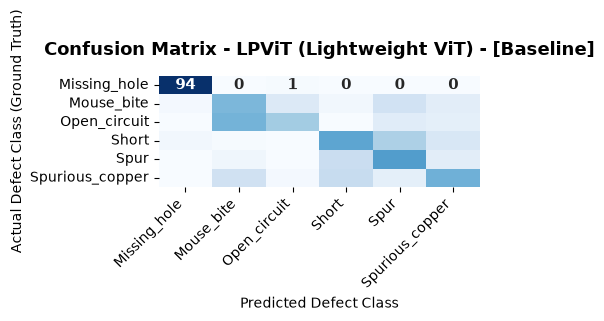


📋 INDUSTRIAL CLASSIFICATION REPORT FOR: CS-ResNet (ResNet18) - [Baseline]
📍 Execution Device: cuda
                 precision    recall  f1-score   support

   Missing_hole       1.00      1.00      1.00        95
     Mouse_bite       1.00      1.00      1.00        89
   Open_circuit       1.00      1.00      1.00        99
          Short       1.00      1.00      1.00       101
           Spur       1.00      1.00      1.00        90
Spurious_copper       1.00      1.00      1.00        99

       accuracy                           1.00       573
      macro avg       1.00      1.00      1.00       573
   weighted avg       1.00      1.00      1.00       573



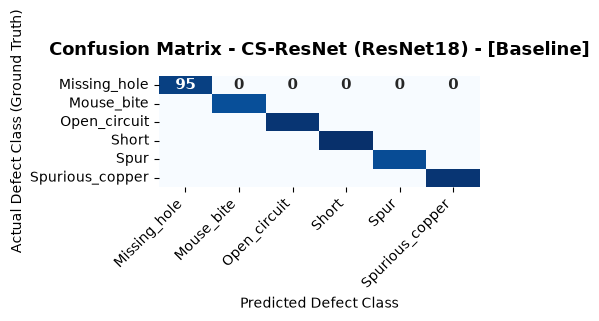


📋 INDUSTRIAL CLASSIFICATION REPORT FOR: MobileNetV3 (Small) - [Baseline]
📍 Execution Device: cpu
                 precision    recall  f1-score   support

   Missing_hole       1.00      1.00      1.00        95
     Mouse_bite       1.00      1.00      1.00        89
   Open_circuit       1.00      1.00      1.00        99
          Short       1.00      0.99      1.00       101
           Spur       0.99      1.00      0.99        90
Spurious_copper       1.00      1.00      1.00        99

       accuracy                           1.00       573
      macro avg       1.00      1.00      1.00       573
   weighted avg       1.00      1.00      1.00       573



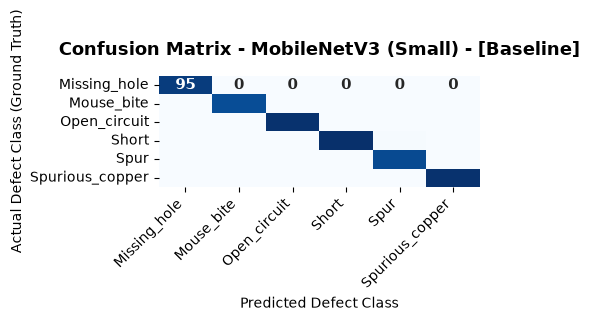


📋 INDUSTRIAL CLASSIFICATION REPORT FOR: AlexNet (Auto-VRS) - [Baseline]
📍 Execution Device: cpu
                 precision    recall  f1-score   support

   Missing_hole       1.00      1.00      1.00        95
     Mouse_bite       1.00      1.00      1.00        89
   Open_circuit       1.00      1.00      1.00        99
          Short       1.00      1.00      1.00       101
           Spur       0.99      0.98      0.98        90
Spurious_copper       0.98      0.99      0.98        99

       accuracy                           0.99       573
      macro avg       0.99      0.99      0.99       573
   weighted avg       0.99      0.99      0.99       573



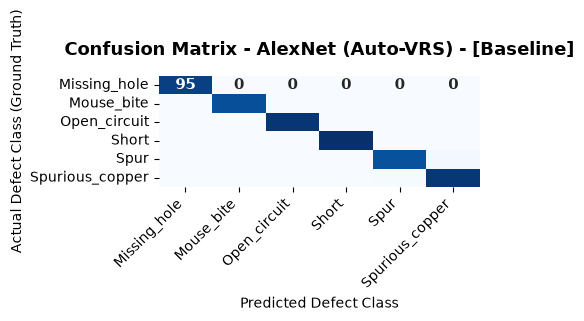

In [31]:
## Baseline

run_experiment(epochs=30, patience=5, mode="baseline")

# ==============================================================================
# BASELINE MODEL EVALUATION (Models Trained From Scratch - No Pre-trained Weights)
# ==============================================================================

# Define targets mapping the baseline models to their designated devices
evaluation_targets_baseline = [
    {
        "model": lpvit_sim, 
        "device": device_gpu, 
        "name": "LPViT (Lightweight ViT) - [Baseline]"
    },
    {
        "model": cs_resnet, 
        "device": device_gpu, 
        "name": "CS-ResNet (ResNet18) - [Baseline]"
    },
    {
        "model": mobilenet, 
        "device": device_cpu, 
        "name": "MobileNetV3 (Small) - [Baseline]"
    },
    {
        "model": alexnet, 
        "device": device_cpu, 
        "name": "AlexNet (Auto-VRS) - [Baseline]"
    }
]

print("📊 Initiating bulk evaluation metrics across all BASELINE models...")
for target in evaluation_targets_baseline:
    evaluate_industrial_metrics(
        model=target["model"],
        dataloader=val_loader,
        device=target["device"],
        model_name=target["name"]
    )

In [ ]:
## Fine Tuned 
# 最大跑 30 轮，5 轮内不下降自动早停
run_experiment(epochs=30, patience=5, mode="finetune")

# ==============================================================================
# FINE-TUNED MODEL EVALUATION (Models Trained with ImageNet Pre-trained Weights)
# ==============================================================================

# Define targets mapping the fine-tuned models to their designated devices
evaluation_targets_finetune = [
    {
        "model": lpvit_finetune, 
        "device": device_gpu, 
        "name": "LPViT (Lightweight ViT) - [Fine-Tune]"
    },
    {
        "model": cs_resnet_finetune, 
        "device": device_gpu, 
        "name": "CS-ResNet (ResNet18) - [Fine-Tune]"
    },
    {
        "model": mobilenet_finetune, 
        "device": device_cpu, 
        "name": "MobileNetV3 (Small) - [Fine-Tune]"
    },
    {
        "model": alexnet_finetune, 
        "device": device_cpu, 
        "name": "AlexNet (Auto-VRS) - [Fine-Tune]"
    }
]

print("📊 Initiating bulk evaluation metrics across all FINE-TUNED models...")
for target in evaluation_targets_finetune:
    evaluate_industrial_metrics(
        model=target["model"],
        dataloader=val_loader,
        device=target["device"],
        model_name=target["name"]
    )

🎯 MODE: [FINE-TUNE] - Training with pre-trained ImageNet weights.

🎬 Training Started: LPViT (Lightweight ViT) [Fine-Tune]
📍 Target Device   : cuda | Max Epochs: 30 | Patience: 5
Epoch 01/30 | Train Loss: 1.1450 | Train Acc: 49.41% | Val Loss: 1.1635 | Val Acc: 49.39% | LR: 0.000997
Epoch 02/30 | Train Loss: 1.0714 | Train Acc: 51.39% | Val Loss: 1.1480 | Val Acc: 50.96% | LR: 0.000989
Epoch 03/30 | Train Loss: 1.1063 | Train Acc: 51.01% | Val Loss: 1.1090 | Val Acc: 52.01% | LR: 0.000976
Epoch 04/30 | Train Loss: 1.0707 | Train Acc: 51.51% | Val Loss: 1.2450 | Val Acc: 46.07% | LR: 0.000957
   ⚠️ [EarlyStopping] Validation loss did not improve. Counter: 1/5
Epoch 05/30 | Train Loss: 1.0789 | Train Acc: 52.06% | Val Loss: 1.0158 | Val Acc: 53.58% | LR: 0.000933
Epoch 06/30 | Train Loss: 1.0928 | Train Acc: 50.42% | Val Loss: 1.3439 | Val Acc: 47.12% | LR: 0.000905
   ⚠️ [EarlyStopping] Validation loss did not improve. Counter: 1/5
Epoch 07/30 | Train Loss: 1.0508 | Train Acc: 53.53% | 

Epoch 10/30 | Train Loss: 0.0004 | Train Acc: 100.00% | Val Loss: 0.0005 | Val Acc: 100.00% | LR: 0.000075
Epoch 11/30 | Train Loss: 0.0034 | Train Acc: 99.83% | Val Loss: 0.0013 | Val Acc: 100.00% | LR: 0.000070
   ⚠️ [EarlyStopping] Validation loss did not improve. Counter: 1/5
Epoch 12/30 | Train Loss: 0.0006 | Train Acc: 100.00% | Val Loss: 0.0003 | Val Acc: 100.00% | LR: 0.000065
Epoch 13/30 | Train Loss: 0.0015 | Train Acc: 99.96% | Val Loss: 0.0003 | Val Acc: 100.00% | LR: 0.000060
   ⚠️ [EarlyStopping] Validation loss did not improve. Counter: 1/5
Epoch 14/30 | Train Loss: 0.0002 | Train Acc: 100.00% | Val Loss: 0.0001 | Val Acc: 100.00% | LR: 0.000055
Epoch 15/30 | Train Loss: 0.0000 | Train Acc: 100.00% | Val Loss: 0.0000 | Val Acc: 100.00% | LR: 0.000050
   ⚠️ [EarlyStopping] Validation loss did not improve. Counter: 1/5
